In [1]:
# Installing PyTorch 

!pip install torch torchvision torchaudio


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Installing  libraries
!pip install transformers datasets scikit-learn


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Reproducibility Setup

import pandas as pd
import numpy as np
import random
import torch

from pathlib import Path

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Reproducibility seed:", SEED)

Reproducibility seed: 42


In [4]:
# Project root configuration

from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\LENOVO\OneDrive\Documents\Strath\Masters\sentiment-analysis-tool


In [5]:
# Load annotated dataset

DATA_PATH = PROJECT_ROOT / "data" / "annotated_data" / "final_annotated_dataset.xlsx"

df = pd.read_excel(DATA_PATH)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (2000, 14)


,text,topic,sentiment,annotator,confidence,match_key,match_text,source,date,channel,product,language,clean_text,match_score
0,i am writing to seek urgent assistance regardi...,Mobile Banking App,negative,annotator_1,high,i am writing to seek urgent assistance regardi...,i am writing to seek urgent assistance regardi...,CRM Tool,04/11/2025 00:00,Service Email,Mobile,english,i am writing to seek urgent assistance regardi...,99.737877
1,name seem to neglect your duty to give the bes...,Mobile Banking App,negative,annotator_1,high,name seem to neglect your duty to give the bes...,name seem to neglect your duty to give the bes...,CRM Tool,05/11/2025 00:00,Service Email,Mobile,english,seem to neglect your duty to give the best bec...,98.245614
2,namere seeking your assistance in providing ...,Payments,negative,annotator_1,high,namere seeking your assistance in providing a ...,namere seeking your assistance in providing a ...,CRM Tool,05/12/2025 00:00,Service Email,Thunes,english,namere seeking your assistance in providing a ...,88.442623
3,reminder on resolving this issue of payment ...,Acccount Issues,negative,annotator_1,high,reminder on resolving this issue of payment on...,reminder on resolving this issue of payment on...,CRM Tool,19/11/2025 00:00,Service Email,Card Online Disputes,english,name name reminder on resolving this issue of ...,97.071130
4,a member of you service and am trying to open...,Mobile Banking App,negative,annotator_1,high,a member of you service and am trying to open ...,a member of you service and am trying to open ...,CRM Tool,25/11/2025 00:00,Service Email,Mobile,english,namename a member of you service and am trying...,97.352342


In [6]:
# Encode sentiment labels as integers

label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

df["label"] = df["sentiment"].str.lower().map(label_map)

print(df[["sentiment","label"]].head())

  sentiment  label
0  negative      0
1  negative      0
2  negative      0
3  negative      0
4  negative      0


In [7]:
df["sentiment"].value_counts()

sentiment
negative    1003
neutral      806
positive     191
Name: count, dtype: int64

In [8]:
# Select variables

X = df["clean_text"]
y = df["label"] # Use the integer column created in cell [47]

print("Features:", len(X))

Features: 2000


In [9]:
# Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Training size:", len(X_train))
print("Test size:", len(X_test))

Training size: 1600
Test size: 400


In [10]:
# Load FinBERT tokenizer

from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

print("FinBERT loaded")

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


FinBERT loaded


In [11]:
# Tokenize the text data

train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

print("Tokenization complete")

Tokenization complete


In [12]:
# Dataset class for PyTorch

import torch

class BankingDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)

In [13]:
# Create dataset objects

train_dataset = BankingDataset(
    train_encodings,
    y_train.tolist()
)

test_dataset = BankingDataset(
    test_encodings,
    y_test.tolist() 
)

print("Datasets ready")

Datasets ready


In [15]:
# Training arguments configuration

from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir=str(PROJECT_ROOT / "models" / "finbert"),

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    evaluation_strategy="epoch",

    seed=SEED,

    report_to="none"
)

print("Training arguments ready")

Training arguments ready


In [16]:
# Evaluation metrics function

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):

    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted"
    )

    acc = accuracy_score(labels, preds)

    return {
        "Accuracy": acc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall
    }

In [17]:
# Trainer setup

from transformers import Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

print("Trainer ready")

Trainer ready


In [18]:
# Start training

trainer.train()

  0%|          | 0/600 [00:00<?, ?it/s]c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                                                     
 33%|███▎      | 200/600 [38:57<27:18,  4.10s/it]c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.377066045999527, 'eval_Accuracy': 0.845, 'eval_F1': 0.8446409812916936, 'eval_Precision': 0.8446422465572642, 'eval_Recall': 0.845, 'eval_runtime': 42.9128, 'eval_samples_per_second': 9.321, 'eval_steps_per_second': 1.165, 'epoch': 1.0}


                                                       
 67%|██████▋   | 400/600 [1:16:31<40:11, 12.06s/it]c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.4455460011959076, 'eval_Accuracy': 0.86, 'eval_F1': 0.8591046421690096, 'eval_Precision': 0.8619560580002653, 'eval_Recall': 0.86, 'eval_runtime': 42.0187, 'eval_samples_per_second': 9.52, 'eval_steps_per_second': 1.19, 'epoch': 2.0}


 83%|████████▎ | 500/600 [1:34:04<11:12,  6.72s/it]   

{'loss': 0.3927, 'grad_norm': 1.0390578508377075, 'learning_rate': 3.3333333333333333e-06, 'epoch': 2.5}


100%|██████████| 600/600 [1:41:41<00:00,  4.42s/it]c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                                                   
100%|██████████| 600/600 [1:42:38<00:00, 10.26s/it]

{'eval_loss': 0.48511725664138794, 'eval_Accuracy': 0.87, 'eval_F1': 0.8696699216699217, 'eval_Precision': 0.8699263018534863, 'eval_Recall': 0.87, 'eval_runtime': 56.6659, 'eval_samples_per_second': 7.059, 'eval_steps_per_second': 0.882, 'epoch': 3.0}
{'train_runtime': 6158.4593, 'train_samples_per_second': 0.779, 'train_steps_per_second': 0.097, 'train_loss': 0.354154847462972, 'epoch': 3.0}


TrainOutput(global_step=600, training_loss=0.354154847462972, metrics={'train_runtime': 6158.4593, 'train_samples_per_second': 0.779, 'train_steps_per_second': 0.097, 'total_flos': 315736101273600.0, 'train_loss': 0.354154847462972, 'epoch': 3.0})

In [19]:
# Evaluate the model

predictions = trainer.predict(test_dataset)

print("Evaluation completed")

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 50/50 [00:34<00:00,  1.46it/s]

Evaluation completed


In [20]:
# Extract predicted labels and true labels for further analysis

predictions = trainer.predict(test_dataset)

y_pred = predictions.predictions.argmax(axis=1)
y_true = y_test.values

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 50/50 [00:55<00:00,  1.10s/it]


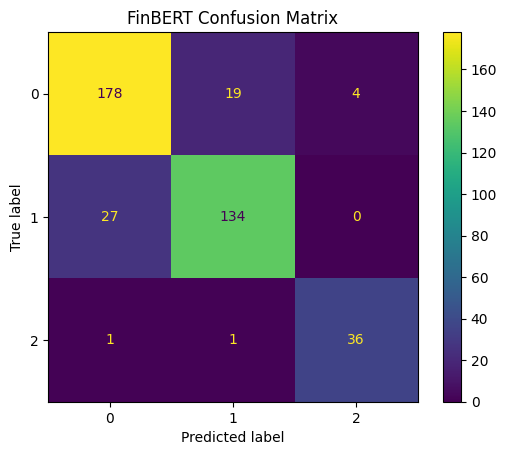

In [21]:
# Confusion matrix visualization

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("FinBERT Confusion Matrix")

plt.show()

In [22]:
# Classification report

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87       201
           1       0.87      0.83      0.85       161
           2       0.90      0.95      0.92        38

    accuracy                           0.87       400
   macro avg       0.88      0.89      0.88       400
weighted avg       0.87      0.87      0.87       400



In [23]:
# Calculate and print individual metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred, average="weighted")

recall = recall_score(y_true, y_pred, average="weighted")

f1 = f1_score(y_true, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.87
Precision: 0.8699263018534863
Recall: 0.87
F1 Score: 0.8696699216699217


In [24]:
# Save the fine-tuned model

MODEL_PATH = PROJECT_ROOT / "models" / "finbert_model"

trainer.save_model(MODEL_PATH)

print("FinBERT model saved")

FinBERT model saved


In [25]:
# Save the results

results = pd.DataFrame({
    "text": X_test,
    "Actual": y_test,
    "Predicted": y_pred
})

OUTPUT_PATH = PROJECT_ROOT / "results"

OUTPUT_PATH.mkdir(exist_ok=True)

results.to_csv(
    OUTPUT_PATH / "finbert_finetuned_results.csv",
    index=False
)

print("Results saved")

Results saved
